In [3]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

In [4]:
from src.journal_api import get_papers_dataframe

df = get_papers_dataframe(
    venue="Transactions of the Association for Computational Linguistics",
    fields_of_study="Computer Science",
    publication_types="JournalArticle",
    date_range="2010-01-01:2025-12-31"
)

df = df[df["abstract"].notna()].copy()
df.head()

,paperId,title,venue,year,openAccessPdf,publicationDate,authors,abstract,month,four_month_section
0,cd0a1d660771c9d2fa42c9446fbc1f441d40e9d1,A Novel Feature-based Bayesian Model for Query...,Transactions of the Association for Computatio...,2012,{'url': 'http://www.mitpressjournals.org/doi/p...,2012-12-10,"[{'authorId': '2386020789', 'name': 'Jiwei Li'...",Supervised learning methods and LDA based topi...,12,3
2,03c605c8b0bdd7ce7e2123ab6394dcc25f70f6a9,Finding Optimal 1-Endpoint-Crossing Trees,Transactions of the Association for Computatio...,2013,{'url': 'http://www.mitpressjournals.org/doi/p...,2013-03-01,"[{'authorId': '2585932', 'name': 'Emily Pitler...",Dependency parsing algorithms capable of produ...,3,1
3,21b3007f967d39e1346bc91e0fc8b3f16121300c,Grounding Action Descriptions in Videos,Transactions of the Association for Computatio...,2013,{'url': 'http://www.mitpressjournals.org/doi/p...,2013-03-31,"[{'authorId': '2485529', 'name': 'Michaela Reg...",Recent work has shown that the integration of ...,3,1
4,22566980b49e2b2d3594f9446f7398da5d344a5c,Branch and Bound Algorithm for Dependency Pars...,Transactions of the Association for Computatio...,2013,{'url': 'http://www.mitpressjournals.org/doi/p...,2013-03-31,"[{'authorId': '2067733840', 'name': 'Xian Qian...",Graph based dependency parsing is inefficient ...,3,1
5,770decd2882956ee419ebbdd79e9253784819a0a,Unsupervised Dependency Parsing with Acoustic ...,Transactions of the Association for Computatio...,2013,{'url': 'http://www.mitpressjournals.org/doi/p...,2013-03-31,"[{'authorId': '12003640', 'name': 'John K. Pat...",Unsupervised parsing is a difficult task that ...,3,1


In [5]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=15
)

X = vectorizer.fit_transform(df["abstract"])

topics = vectorizer.get_feature_names_out()
topics

array(['abstract', 'based', 'data', 'language', 'languages', 'learning',
       'model', 'models', 'performance', 'results', 'task', 'tasks',
       'text', 'training', 'word'], dtype=object)

In [11]:
topic_mapping = {
    "model": "Language Models",
    "models": "Language Models",
    "learning": "Machine Learning",
    "training": "Machine Learning",
    "data": "Machine Learning",

    "language": "NLP Core",
    "languages": "NLP Core",
    "text": "NLP Core",
    "word": "NLP Core",

    "task": "Applications",
    "tasks": "Applications",

    "performance": "Evaluation",
    "results": "Evaluation",

    "abstract": "Other",
    "based": "Other"
}

In [12]:
import numpy as np

X_array = X.toarray()

top_topic_idx = np.argmax(X_array, axis=1)

df["topic"] = [topics[i] for i in top_topic_idx]

df[["year", "title", "topic"]].head()

,year,title,topic
0,2012,A Novel Feature-based Bayesian Model for Query...,learning
2,2013,Finding Optimal 1-Endpoint-Crossing Trees,language
3,2013,Grounding Action Descriptions in Videos,text
4,2013,Branch and Bound Algorithm for Dependency Pars...,based
5,2013,Unsupervised Dependency Parsing with Acoustic ...,word


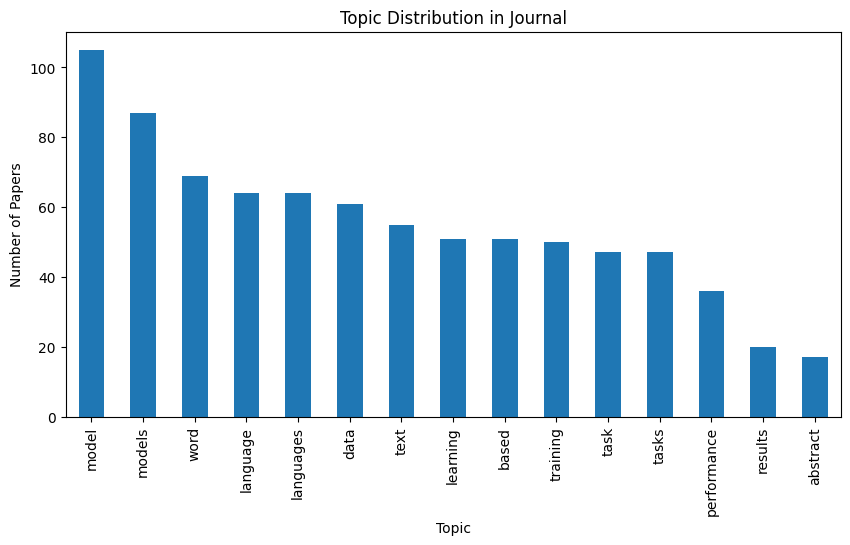

In [7]:
topic_counts = df["topic"].value_counts()

topic_counts.plot(kind="bar", figsize=(10,5))
plt.title("Topic Distribution in Journal")
plt.xlabel("Topic")
plt.ylabel("Number of Papers")
plt.show()

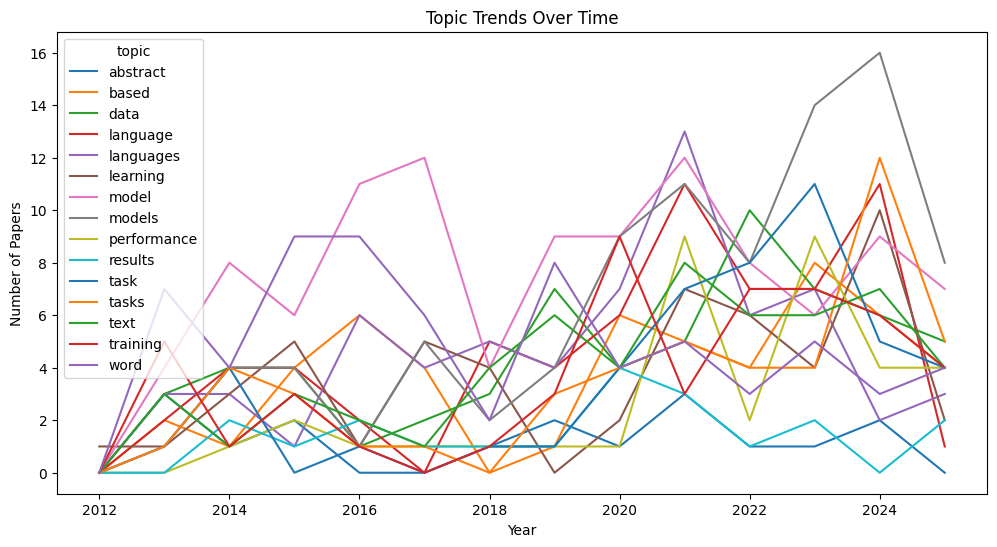

In [8]:
topic_trends = df.groupby(["year", "topic"]).size().unstack(fill_value=0)

topic_trends.plot(figsize=(12,6))
plt.title("Topic Trends Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Papers")
plt.show()

In [9]:
# if you want, reuse alignment_score from Phase 1
# or recompute quickly if needed

from src.embeddings import EmbeddingModel
from src.scoring import compute_similarity

embedder = EmbeddingModel()

journal_scope = """
This journal publishes research in computational linguistics,
natural language processing, machine learning for language understanding,
syntax, semantics, discourse, multilingual NLP, and language generation.
"""

scope_embedding = embedder.encode_text(journal_scope)
article_embeddings = embedder.encode_list(df["abstract"].tolist())

df["alignment_score"] = compute_similarity(article_embeddings, scope_embedding)

Batches:   0%|          | 0/26 [00:00<?, ?it/s]

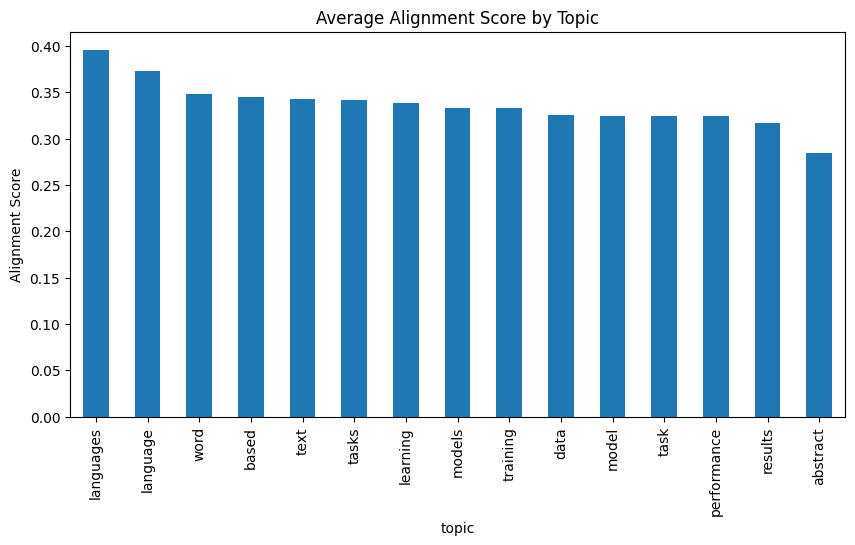

In [10]:
topic_alignment = df.groupby("topic")["alignment_score"].mean().sort_values(ascending=False)

topic_alignment.plot(kind="bar", figsize=(10,5))
plt.title("Average Alignment Score by Topic")
plt.ylabel("Alignment Score")
plt.show()

In [13]:
df["clean_topic"] = df["topic"].map(topic_mapping).fillna("Other")

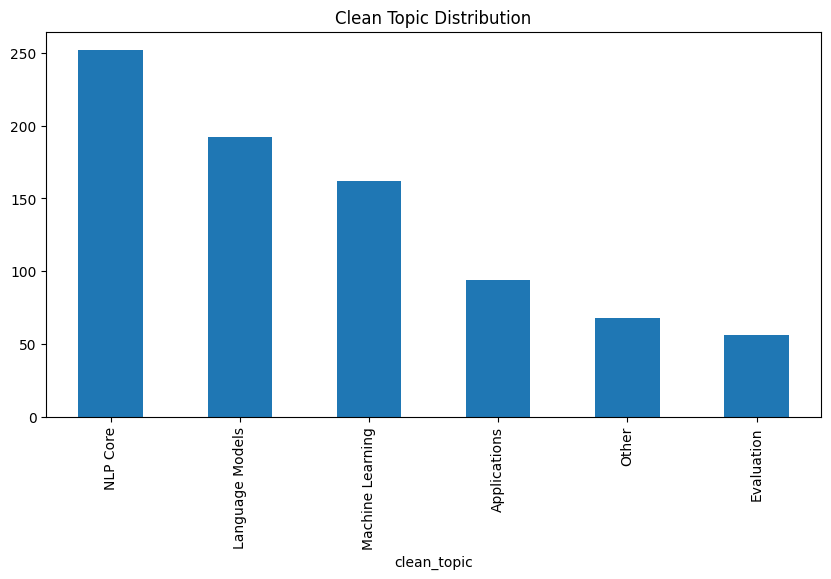

In [14]:
df["clean_topic"].value_counts().plot(kind="bar", figsize=(10,5))
plt.title("Clean Topic Distribution")
plt.show()

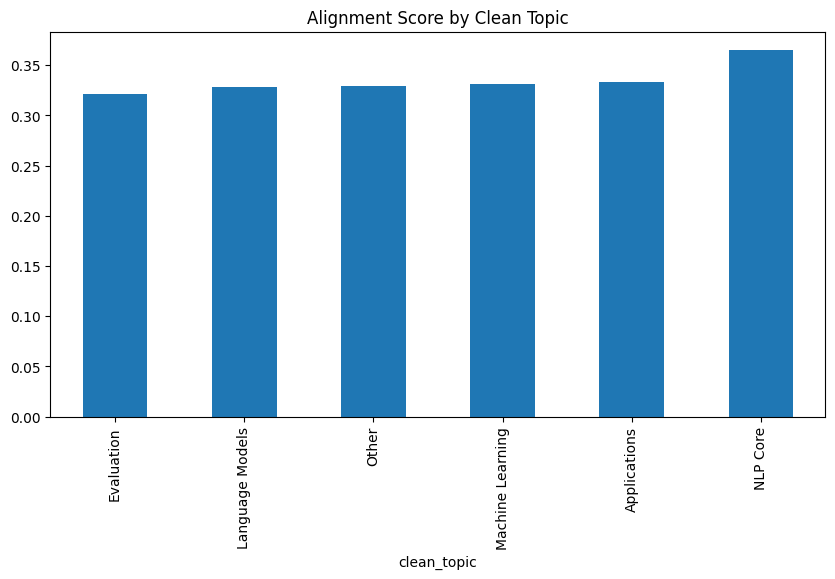

In [15]:
df.groupby("clean_topic")["alignment_score"].mean().sort_values().plot(kind="bar", figsize=(10,5))
plt.title("Alignment Score by Clean Topic")
plt.show()

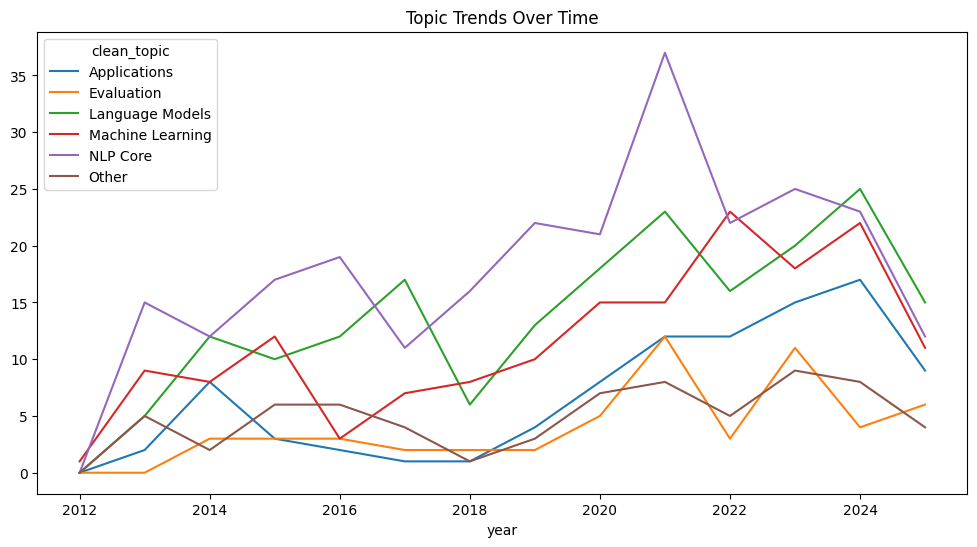

In [16]:
topic_trends = df.groupby(["year", "clean_topic"]).size().unstack(fill_value=0)

topic_trends.plot(figsize=(12,6))
plt.title("Topic Trends Over Time")
plt.show()